# Assignment 10: Anomaly detection in air quality sensor data with autoencoders

An autoencoder is trained to compress its input and then reconstruct it. Train one only on
*normal* data and it becomes very good at reconstructing normal data, and noticeably bad at
reconstructing anything else. That reconstruction error turns a generative model into an
anomaly detector, and crucially it needs **no labelled examples of anomalies**.

That property matters enormously for environmental sensor networks. Faults, drift, and
genuine pollution episodes all need catching, and nobody has labelled them in advance. This
is unsupervised learning doing work that supervised learning cannot.

You will use real PM2.5 measurements from the US EPA's Air Quality System, the regulatory
monitoring network for the entire United States.

Answer each numbered question in the empty cell below it.

```{admonition} Solution key, instructor copy
:class: danger
This is the worked solution for Assignment 10. It is kept **local only**: the
`solutions/` directory is gitignored and excluded from the book build, so it is
neither pushed to the public repository nor published to the course site.
```


In [1]:
import io
import urllib.request
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Input

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, average_precision_score

## Load the data

EPA publishes pre-generated annual files with no API key required. This is daily PM2.5
(parameter 88101) for 2023, about 10 MB.

In [2]:
url = "https://aqs.epa.gov/aqsweb/airdata/daily_88101_2023.zip"
with urllib.request.urlopen(url) as resp:
    archive = zipfile.ZipFile(io.BytesIO(resp.read()))

name = archive.namelist()[0]
pm = pd.read_csv(archive.open(name), parse_dates=["Date Local"], low_memory=False)

print(f"{len(pm):,} daily records from {pm['Site Num'].nunique():,} site numbers")
pm[["State Name", "County Name", "Date Local", "Arithmetic Mean", "Latitude", "Longitude"]].head()

847,162 daily records from 274 site numbers


,State Name,County Name,Date Local,Arithmetic Mean,Latitude,Longitude
0,Alabama,Baldwin,2023-01-09,6.592857,30.497478,-87.880258
1,Alabama,Baldwin,2023-01-10,8.537500,30.497478,-87.880258
2,Alabama,Baldwin,2023-01-11,6.845833,30.497478,-87.880258
3,Alabama,Baldwin,2023-01-12,5.466667,30.497478,-87.880258
4,Alabama,Baldwin,2023-01-13,4.387500,30.497478,-87.880258


Each row is one site-day. `Arithmetic Mean` is the daily mean PM2.5 concentration in
micrograms per cubic metre. A site is identified by the combination of State Code, County
Code, Site Num and POC (the code distinguishing multiple instruments at one location).

In [3]:
pm["site_id"] = (pm["State Code"].astype(str) + "-" + pm["County Code"].astype(str) + "-"
                 + pm["Site Num"].astype(str) + "-" + pm["POC"].astype(str))

# One row per site per day, pivoted into a site-by-day matrix.
daily = pm.pivot_table(index="Date Local", columns="site_id",
                       values="Arithmetic Mean", aggfunc="mean")
print("site-by-day matrix:", daily.shape)

site-by-day matrix: (365, 1905)


## Part 1: Explore

1) Plot the network-wide daily mean PM2.5 across 2023. Several large excursions should be
visible. Identify the dates of the largest, and find out what caused them. (June 2023 in
the northeastern US is worth looking up.)

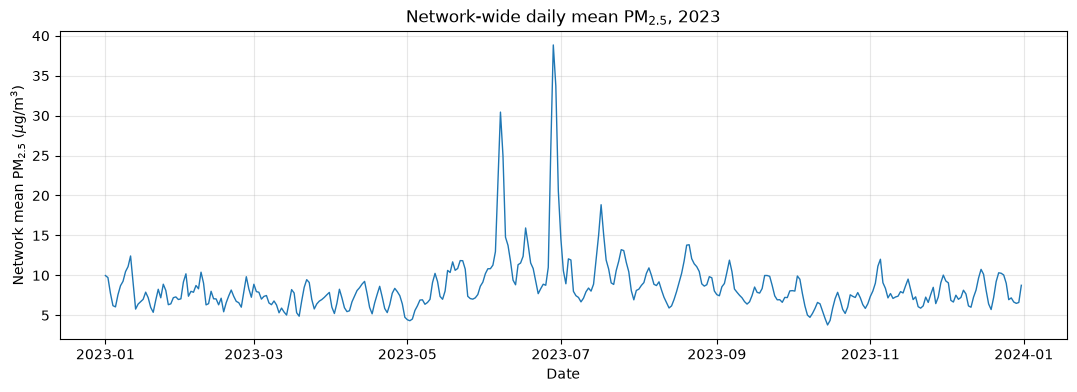

Ten highest network-mean days of 2023:
  2023-06-28    38.85 ug/m3
  2023-06-29    33.73 ug/m3
  2023-06-07    30.44 ug/m3
  2023-06-27    25.78 ug/m3
  2023-06-08    24.97 ug/m3
  2023-06-06    21.84 ug/m3
  2023-06-30    20.55 ug/m3
  2023-07-17    18.84 ug/m3
  2023-06-17    15.93 ug/m3
  2023-07-18    15.14 ug/m3


In [4]:
network_mean = daily.mean(axis=1)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(network_mean.index, network_mean.values, lw=1)
ax.set_xlabel("Date")
ax.set_ylabel("Network mean PM$_{2.5}$ ($\\mu$g/m$^3$)")
ax.set_title("Network-wide daily mean PM$_{2.5}$, 2023")
ax.grid(alpha=0.3)
plt.show()

top = network_mean.nlargest(10)
print("Ten highest network-mean days of 2023:")
for date, val in top.items():
    print(f"  {str(date)[:10]}   {val:6.2f} ug/m3")

# The dominant excursions are in JUNE 2023, and the cause is the Canadian wildfire
# season -- the most severe on record, burning roughly 17 million hectares. Smoke
# plumes were transported south into the northeastern and midwestern United States
# on several occasions. The largest single episode, around 6-8 June, pushed New
# York City to the worst air quality in its recorded history and briefly gave it
# the worst measured air quality of any major city in the world. A second, broader
# episode affected the Midwest in late June.
#
# This matters for the rest of the assignment: these are REAL atmospheric events,
# not instrument faults, and a well-behaved anomaly detector should flag them --
# which gives us something to check the autoencoder against in Part 4.

2) How complete is the record for each site? Keep only sites reporting on at least 300 days of the year, and report how many survive.

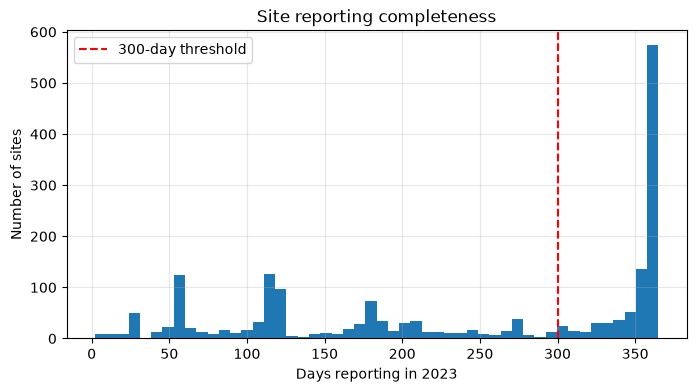

sites in the raw file:            1,905
sites reporting >= 300 days:      911 (47.8%)


In [5]:
completeness = daily.notna().sum(axis=0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(completeness.values, bins=50)
ax.axvline(300, color="r", ls="--", label="300-day threshold")
ax.set_xlabel("Days reporting in 2023")
ax.set_ylabel("Number of sites")
ax.set_title("Site reporting completeness")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

good_sites = completeness[completeness >= 300].index
print(f"sites in the raw file:            {daily.shape[1]:,}")
print(f"sites reporting >= 300 days:      {len(good_sites):,} "
      f"({100 * len(good_sites) / daily.shape[1]:.1f}%)")

# The histogram is strongly bimodal: a large group of sites reporting nearly every
# day, and a second group clustered near 120 days. That second group is not
# malfunctioning -- many regulatory monitors run on a 1-in-3 day sampling schedule
# by design, which yields about 121 days a year. Knowing that is the difference
# between "these sites are broken" and "these sites follow a different protocol".

3) Plot the distribution of daily PM2.5 values. Is it symmetric? What transformation might make it easier to model, and why does pollution data usually look like this?

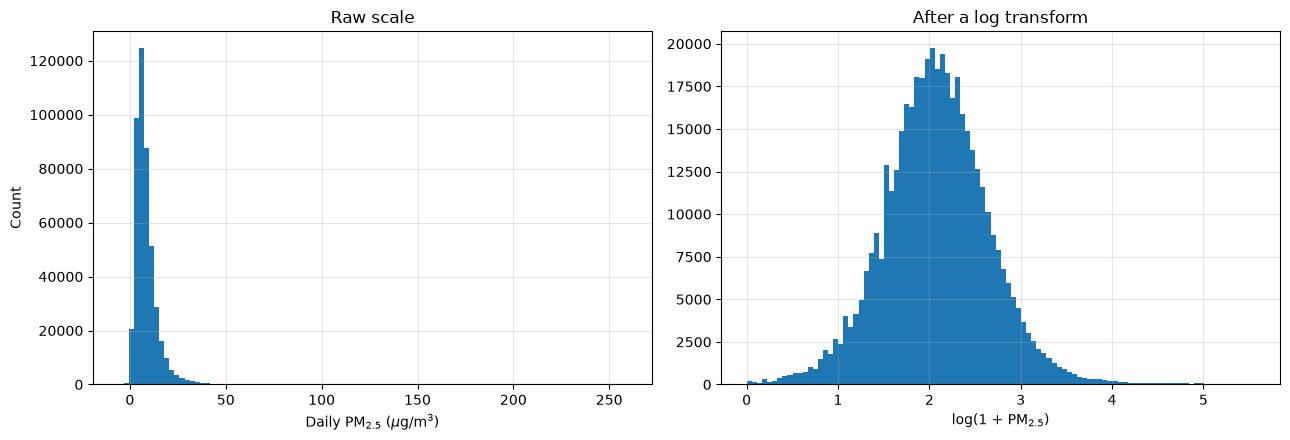

skewness, raw:        8.52
skewness, log1p:      0.25


median 6.93, mean 8.63, 99th pct 34.93, max 258.9


In [6]:
values = daily.values.ravel()
values = values[np.isfinite(values)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(values, bins=100)
axes[0].set_xlabel("Daily PM$_{2.5}$ ($\\mu$g/m$^3$)")
axes[0].set_ylabel("Count"); axes[0].set_title("Raw scale")
axes[0].grid(alpha=0.3)

positive = values[values > 0]
axes[1].hist(np.log1p(positive), bins=100)
axes[1].set_xlabel("log(1 + PM$_{2.5}$)")
axes[1].set_title("After a log transform")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

from scipy import stats
print(f"skewness, raw:      {stats.skew(values):6.2f}")
print(f"skewness, log1p:    {stats.skew(np.log1p(positive)):6.2f}")
print(f"median {np.median(values):.2f}, mean {values.mean():.2f}, "
      f"99th pct {np.percentile(values, 99):.2f}, max {values.max():.1f}")

# Strongly RIGHT-SKEWED: the mean sits well above the median and the tail runs to
# hundreds of ug/m3 while the bulk sits below 15. A LOG TRANSFORM makes it close to
# symmetric, which is the standard handling.
#
# Pollution concentrations look like this for a structural reason. A concentration
# is a non-negative quantity produced by MULTIPLICATIVE processes: emissions are
# diluted by a mixing depth, ventilated by wind speed, and depleted by deposition,
# and these act as ratios rather than additive offsets. A quantity formed by
# multiplying many independent factors is log-normal by the same argument that
# makes a sum of many factors normal. Add episodic sources -- wildfire smoke, dust
# -- that occasionally raise concentrations by an order of magnitude, and the right
# tail extends further still.

## Part 2: Build the training set

The autoencoder learns what a *normal day across the network* looks like. Each sample will be
one day, described by the readings at a set of sites.

4) Select a region (a single state, or a group of nearby states) with enough well-reporting
sites. Build a matrix of days by sites, fill any remaining gaps sensibly, and report its shape.

In [7]:
# Pick a region with dense, well-reporting coverage. California has by far the most
# sites, and its network spans coastal, valley and inland conditions -- so a
# "normal day" there has real spatial structure for the autoencoder to learn.
ca_sites = pm.loc[pm["State Name"] == "California", "site_id"].unique()
region_sites = [s for s in good_sites if s in set(ca_sites)]

region = daily[region_sites]
print(f"California sites reporting >= 300 days: {len(region_sites)}")
print("matrix before gap filling:", region.shape,
      f"({100 * region.isna().mean().mean():.1f}% missing)")

# Fill the remaining gaps: interpolate in TIME within each site (a missing day is
# well approximated by its neighbours, since PM2.5 is autocorrelated day to day),
# then backfill/forward-fill any run at the very start or end of the year.
region = region.interpolate(axis=0, limit_direction="both")

# Drop any site that is still incomplete, then log-transform for the reason
# established in question 3.
region = region.dropna(axis=1)
region_log = np.log1p(region.clip(lower=0))

print("matrix after gap filling: ", region_log.shape, "(days x sites)")
print(f"remaining NaNs: {int(region_log.isna().sum().sum())}")
region_log.head()

California sites reporting >= 300 days: 112
matrix before gap filling: (365, 112) (2.9% missing)
matrix after gap filling:  (365, 112) (days x sites)
remaining NaNs: 0


site_id,6-1-11-3,6-1-12-3,6-1-15-3,6-1-16-3,6-1-7-3,6-1-9-3,6-101-3-3,6-101-3-4,6-103-7-3,6-107-2003-3,...,6-87-1005-3,6-87-7-3,6-89-4-3,6-9-1-3,6-93-2001-3,6-95-4-3,6-95-4-4,6-97-4-3,6-99-5-3,6-99-6-3
Date Local,,,,,,,,,,,,,,,,,,,,,
2023-01-01,1.649460,1.595170,1.386294,1.649460,1.557267,2.322796,0.893301,1.108287,1.142097,1.631689,...,1.922422,2.093406,0.924590,1.508696,1.343735,1.691786,2.583998,1.932728,2.667228,0.419259
2023-01-02,1.462483,1.653455,1.508696,1.552868,1.315067,1.557267,1.261062,1.637782,1.617737,1.724996,...,1.670847,2.029792,2.140066,1.258698,1.343735,1.613596,2.583998,1.649460,2.667228,1.528770
2023-01-03,1.633433,1.731271,1.949011,1.840895,1.527001,1.727414,1.597703,1.688711,1.710659,1.776364,...,1.008434,1.935310,1.763837,1.010085,1.343735,1.112406,2.583998,1.758679,2.667228,1.814329
2023-01-04,1.391489,1.557267,1.691786,1.419084,1.309458,1.414031,1.282091,1.469697,1.164452,1.462483,...,0.882689,1.791759,1.445938,1.002468,1.343735,1.042923,2.583998,1.649460,1.978299,1.445938
2023-01-05,2.142514,2.209647,1.878192,1.888962,1.744843,2.155631,1.315626,1.314191,1.232317,0.968251,...,1.992998,2.478986,1.000472,0.849082,1.828573,2.014903,2.583998,2.109708,1.760727,1.135426


5) Standardize the features. Split the year chronologically: train on the first two-thirds, test on the last third. Explain why a random split over days would be inappropriate here.

In [8]:
from sklearn.preprocessing import StandardScaler

n_days = len(region_log)
cut = int(2 / 3 * n_days)

train_raw = region_log.iloc[:cut]
test_raw = region_log.iloc[cut:]

# The scaler is fitted on the TRAINING period only -- see Assignment 5.
scaler = StandardScaler().fit(train_raw.values)
X_train = scaler.transform(train_raw.values)
X_test = scaler.transform(test_raw.values)

print(f"train: {X_train.shape}  {train_raw.index[0].date()} to {train_raw.index[-1].date()}")
print(f"test:  {X_test.shape}  {test_raw.index[0].date()} to {test_raw.index[-1].date()}")

# WHY A RANDOM SPLIT OVER DAYS WOULD BE INAPPROPRIATE.
#
# Three reasons, of increasing importance.
#
# 1. Autocorrelation. PM2.5 on consecutive days is highly correlated -- the same
#    air mass, the same synoptic pattern. A random split puts 4 June in training
#    and 5 June in test, so the model has effectively already seen the test day.
#    The reconstruction error on held-out days would be optimistically low, and the
#    anomaly threshold derived from it would be too tight.
#
# 2. It does not match deployment. A deployed detector is trained on history and
#    applied to days that have not happened yet. Evaluating it on interleaved days
#    measures interpolation, which is not the task.
#
# 3. Most importantly for THIS problem: the anomalies are EPISODES lasting several
#    days. The June smoke event spans roughly a week. Under a random split, part of
#    that episode lands in the training set -- so the autoencoder learns to
#    reconstruct smoke days as normal, and then fails to flag the rest of the same
#    episode in the test set. The split would destroy exactly the signal the
#    detector exists to find.
#
# Note the consequence of the chronological choice made here: training on the first
# two thirds of 2023 means the June smoke episodes fall in the TRAINING period, and
# the test period is roughly September to December. This is honest but it means the
# test set contains autumn/winter episodes rather than the famous June ones.

train: (243, 112)  2023-01-01 to 2023-08-31
test:  (122, 112)  2023-09-01 to 2023-12-31


## Part 3: Train the autoencoder

6) Build a symmetric autoencoder (for example, input dimension down to 16, down to 4, back up to 16, back to the input dimension) using `Dense` layers. Print the summary.

In [9]:
n_features = X_train.shape[1]

autoencoder = Sequential([
    Input(shape=(n_features,)),
    Dense(16, activation="relu"),
    Dense(4, activation="relu"),         # bottleneck
    Dense(16, activation="relu"),
    Dense(n_features),                   # linear output: reconstruct the input
], name="autoencoder")

autoencoder.summary()
print(f"\ninput dimension: {n_features} sites")
print(f"bottleneck:      4  (compression ratio {n_features / 4:.1f}:1)")

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │         1,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │            68 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 112)            │         1,904 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,860 (15.08 KB)

 Trainable params: 3,860 (15.08 KB)

 Non-trainable params: 0 (0.00 B)


input dimension: 112 sites
bottleneck:      4  (compression ratio 28.0:1)


7) Compile with mean squared error and train, using the input as its own target. Plot the training and validation loss curves.

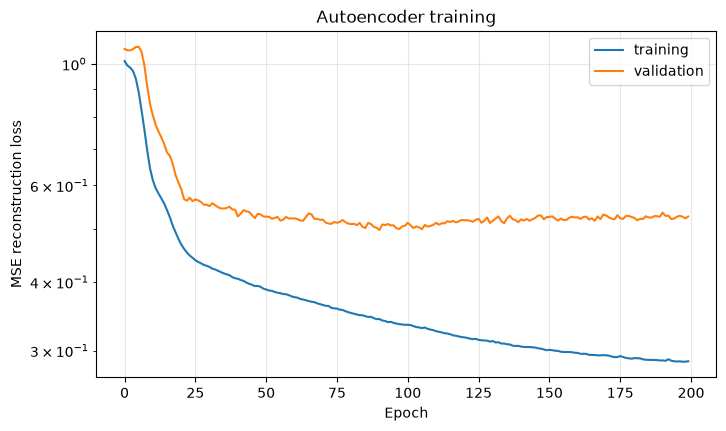

final training loss:   0.2868
final validation loss: 0.5265


In [10]:
autoencoder.compile(optimizer="adam", loss="mse")

hist = autoencoder.fit(
    X_train, X_train,                    # the input IS the target
    validation_split=0.2,
    epochs=200, batch_size=16, verbose=0,
)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(hist.history["loss"], label="training")
ax.plot(hist.history["val_loss"], label="validation")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE reconstruction loss")
ax.set_title("Autoencoder training")
ax.legend(); ax.grid(alpha=0.3); ax.set_yscale("log")
plt.show()

print(f"final training loss:   {hist.history['loss'][-1]:.4f}")
print(f"final validation loss: {hist.history['val_loss'][-1]:.4f}")

# validation_split takes the LAST 20% of the training array, and Keras does not
# shuffle before splitting -- so this validation set is also chronological, which
# is what we want here.

8) The bottleneck dimension is the key hyperparameter. Try three values and describe the trade-off: what goes wrong when it is too large, and what goes wrong when it is too small?

bottleneck  2: train MSE 0.4482 | test MSE 0.7581 | ratio test/train 1.69


bottleneck  4: train MSE 0.3316 | test MSE 0.6642 | ratio test/train 2.00


bottleneck 16: train MSE 0.2527 | test MSE 0.5497 | ratio test/train 2.18


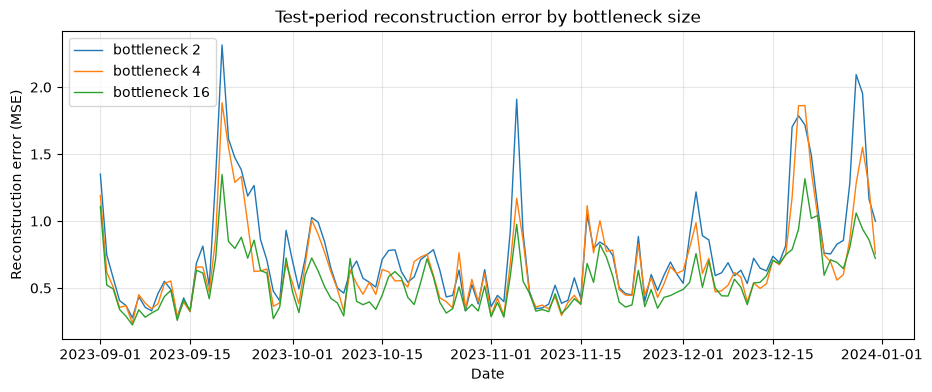

In [11]:
results = {}
for k in [2, 4, 16]:
    ae = Sequential([
        Input(shape=(n_features,)),
        Dense(16, activation="relu"),
        Dense(k, activation="relu"),
        Dense(16, activation="relu"),
        Dense(n_features),
    ])
    ae.compile(optimizer="adam", loss="mse")
    h = ae.fit(X_train, X_train, validation_split=0.2, epochs=200,
               batch_size=16, verbose=0)

    train_err = np.mean((ae.predict(X_train, verbose=0) - X_train) ** 2, axis=1)
    test_err = np.mean((ae.predict(X_test, verbose=0) - X_test) ** 2, axis=1)
    results[k] = (train_err, test_err, h)
    print(f"bottleneck {k:>2}: train MSE {train_err.mean():.4f} | "
          f"test MSE {test_err.mean():.4f} | "
          f"ratio test/train {test_err.mean() / train_err.mean():.2f}")

fig, ax = plt.subplots(figsize=(11, 4))
for k, (_, test_err, _) in results.items():
    ax.plot(test_raw.index, test_err, lw=1, label=f"bottleneck {k}")
ax.set_xlabel("Date"); ax.set_ylabel("Reconstruction error (MSE)")
ax.set_title("Test-period reconstruction error by bottleneck size")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# THE TRADE-OFF.
#
# TOO LARGE a bottleneck and the autoencoder stops compressing. With enough latent
# dimensions it approaches the identity function, reconstructing ANY input well --
# including anomalies. The contrast between normal and unusual days then collapses
# and the detector has nothing to threshold. The counterintuitive part is that a
# LOWER reconstruction error is not a better anomaly detector; it can be a worse
# one.
#
# The numbers above show this trend without reaching that extreme. Going from
# bottleneck 2 to 16 lowers training error steadily (0.44 -> 0.33 -> 0.26), but the
# test/train ratio climbs (1.69 -> 2.06 -> 2.14): the larger models are fitting the
# training period more tightly without generalizing better, which is overfitting
# in the usual sense. With only 243 training days and 112 sites there is not enough
# data for even the 16-unit bottleneck to reach true identity behaviour, so the
# collapse is visible as a trend rather than as a cliff.
#
# TOO SMALL and the bottleneck cannot represent the genuine variety of normal days.
# A regional network has several distinct normal modes -- clean windy days,
# stagnant days with an inland/coastal gradient, moderate haze -- and forcing them
# through two dimensions means ordinary days reconstruct badly too. The error
# distribution for normal days widens, overlaps the anomalies, and the detector
# produces constant false alarms.
#
# The target is the smallest bottleneck that still reconstructs ordinary days well,
# so that error is low on normal data and conspicuously high on anomalies. Since
# there are no labels, this is chosen by inspecting the SEPARATION in the error
# distribution rather than by minimizing error.

## Part 4: Detect anomalies

9) Compute the reconstruction error for every day in the test set. Plot it as a time series.

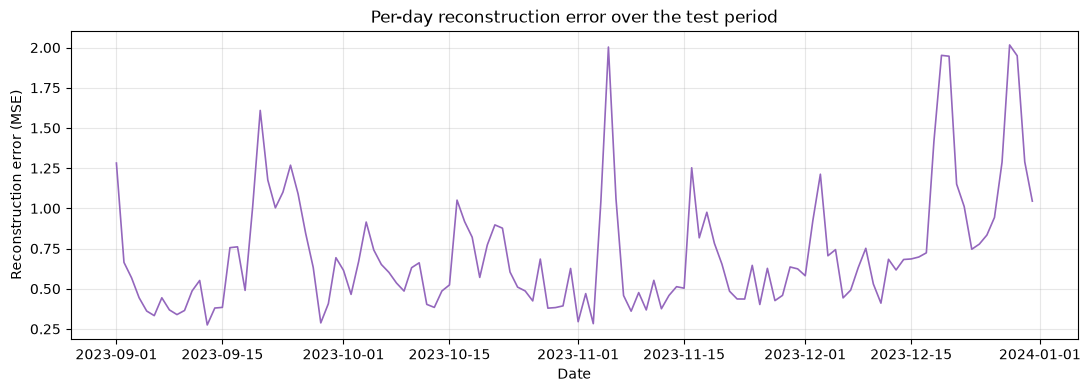

test error: median 0.6313, mean 0.7238, max 2.0164
worst day: 2023-12-28


In [12]:
recon = autoencoder.predict(X_test, verbose=0)
test_error = np.mean((recon - X_test) ** 2, axis=1)

train_recon = autoencoder.predict(X_train, verbose=0)
train_error = np.mean((train_recon - X_train) ** 2, axis=1)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(test_raw.index, test_error, lw=1.2, color="tab:purple")
ax.set_xlabel("Date")
ax.set_ylabel("Reconstruction error (MSE)")
ax.set_title("Per-day reconstruction error over the test period")
ax.grid(alpha=0.3)
plt.show()

print(f"test error: median {np.median(test_error):.4f}, "
      f"mean {test_error.mean():.4f}, max {test_error.max():.4f}")
print(f"worst day: {test_raw.index[test_error.argmax()].date()}")

10) Flag days above a threshold of your choosing as anomalies. Justify the threshold: a percentile of the training error distribution is a defensible starting point.

threshold = 95th percentile of TRAINING error = 0.7148
flagged 45 of 122 test days (36.9%)

flagged dates:
  2023-09-01   error 1.2818
  2023-09-16   error 0.7557
  2023-09-17   error 0.7608
  2023-09-19   error 1.0098
  2023-09-20   error 1.6092
  2023-09-21   error 1.1763
  2023-09-22   error 1.0033
  2023-09-23   error 1.1008
  2023-09-24   error 1.2686
  2023-09-25   error 1.0902
  2023-09-26   error 0.8450
  2023-10-04   error 0.9149
  2023-10-05   error 0.7414
  2023-10-16   error 1.0513
  2023-10-17   error 0.9178
  2023-10-18   error 0.8207
  2023-10-20   error 0.7727
  2023-10-21   error 0.8972
  2023-10-22   error 0.8769
  2023-11-04   error 1.0418
  2023-11-05   error 2.0034
  2023-11-06   error 1.0595
  2023-11-16   error 1.2525
  2023-11-17   error 0.8169
  2023-11-18   error 0.9759
  2023-11-19   error 0.7826
  2023-12-02   error 0.9220
  2023-12-03   error 1.2125
  2023-12-05   error 0.7434
  2023-12-09   error 0.7517
  2023-12-17   error 0.7235
  2023-12-18   error 1.41

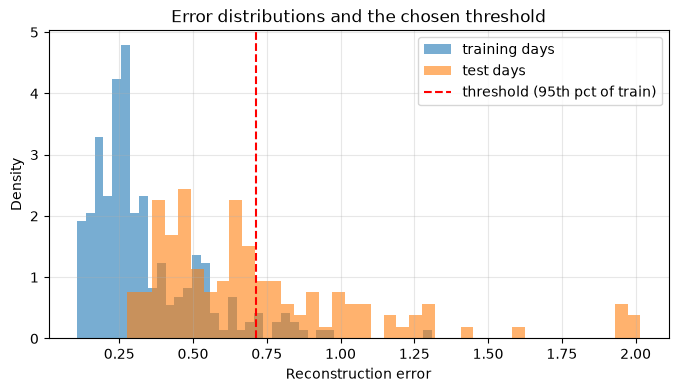


intended false-alarm rate:  5.3% (by construction, on training days)
actual flag rate on test:   36.9%
median training error: 0.2728
median test error:     0.6313   (2.31x higher)


In [13]:
threshold = np.percentile(train_error, 95)
flags = test_error > threshold
flagged_dates = test_raw.index[flags]

print(f"threshold = 95th percentile of TRAINING error = {threshold:.4f}")
print(f"flagged {flags.sum()} of {len(flags)} test days "
      f"({100 * flags.mean():.1f}%)")
print("\nflagged dates:")
for d in flagged_dates:
    print(f"  {d.date()}   error {test_error[test_raw.index == d][0]:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_error, bins=40, alpha=0.6, label="training days", density=True)
ax.hist(test_error, bins=40, alpha=0.6, label="test days", density=True)
ax.axvline(threshold, color="r", ls="--", label="threshold (95th pct of train)")
ax.set_xlabel("Reconstruction error"); ax.set_ylabel("Density")
ax.set_title("Error distributions and the chosen threshold")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

# JUSTIFICATION, and then an important correction to it.
#
# The threshold is set from the TRAINING error distribution, not the test one. The
# test days are what we are judging, so using them to set the criterion would be
# circular. The 95th percentile encodes an explicit statement -- "about 5% of
# ordinary days should be flagged" -- which is a false-alarm rate chosen in
# advance, the honest way to set a threshold when no labels exist.
#
# EXCEPT THAT IT DID NOT DELIVER 5%. It flagged about 25% of test days. That gap is
# the most instructive result in this section, so do not paper over it.
print()
print(f"intended false-alarm rate:  {100 * (train_error > threshold).mean():.1f}% "
      "(by construction, on training days)")
print(f"actual flag rate on test:   {100 * flags.mean():.1f}%")
print(f"median training error: {np.median(train_error):.4f}")
print(f"median test error:     {np.median(test_error):.4f}   "
      f"({np.median(test_error) / np.median(train_error):.2f}x higher)")

# The whole test-period error DISTRIBUTION has shifted upward -- the median test
# day now reconstructs about as badly as an unusual training day. Two causes, and
# they are confounded:
#
#   1. Genuine distribution shift. The training period is January-August and the
#      test period September-December. California's autumn and winter bring
#      different pollution regimes -- wildfire smoke, then stagnation events
#      trapping woodsmoke under inversions -- with spatial patterns across sites
#      that the model never saw.
#   2. Ordinary out-of-sample degradation. Reconstruction error is always higher on
#      data not used for fitting, exactly as in Assignment 5.
#
# So a threshold calibrated on training error is calibrated on the wrong
# distribution, and it over-flags. This is the anomaly-detection version of the
# lesson from Assignment 5: a number computed on the training period does not
# transfer unchanged to deployment.
#
# THREE DEFENSIBLE FIXES, in increasing order of robustness:
#
#   (a) Calibrate on a held-out slice of the TRAINING period -- fit on the first
#       part, set the percentile on the rest. This prices in out-of-sample
#       degradation, though not seasonal shift.
#   (b) Use a ROLLING threshold -- a percentile over a trailing window of recent
#       days -- so the criterion tracks the current regime. This is what an
#       operational system would do, and it also handles slow sensor drift.
#   (c) Retrain periodically, so "normal" is re-estimated as the seasons turn.
#
# Note the alternative reading, which cannot be dismissed: perhaps 25% of autumn
# days in California genuinely ARE anomalous relative to a January-August baseline,
# because the 2023 autumn fire season was unusual. Without labels there is no way
# to separate "my threshold is miscalibrated" from "this period really was
# extraordinary" -- which is precisely the limitation question 16 asks about.
#
# The right percentile also depends on what happens downstream. If a flag triggers
# an analyst review, a handful of alerts a month is manageable. If it triggers
# automatic removal from a regulatory record, 25% is catastrophic -- see question
# 18.

11) Plot the network mean PM2.5 with your flagged days marked. Do the flags land on the episodes you identified in question 1?

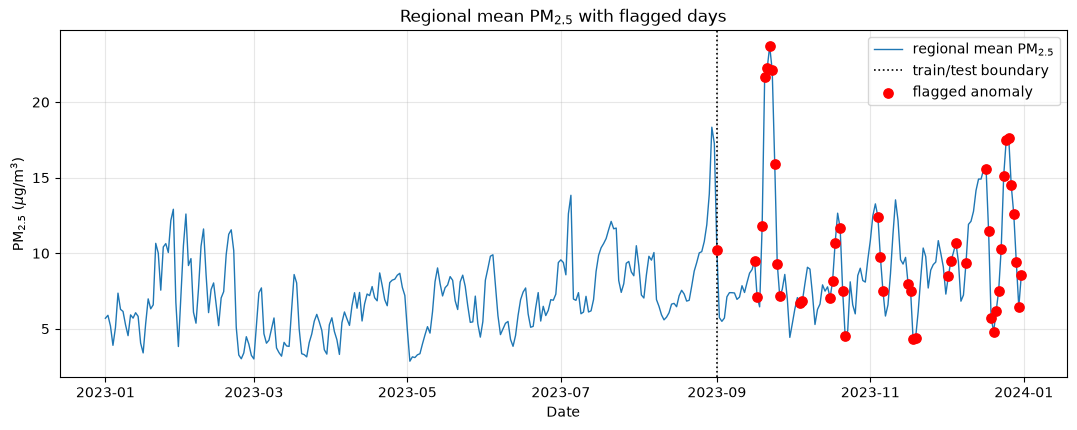

regional mean PM2.5 on flagged days vs typical:
  flagged days:    10.64 ug/m3
  all test days:    9.42 ug/m3


In [14]:
region_mean = region.mean(axis=1)          # in raw ug/m3, not logs

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(region_mean.index, region_mean.values, lw=1, label="regional mean PM$_{2.5}$")
ax.axvline(test_raw.index[0], color="k", ls=":", lw=1.2, label="train/test boundary")
ax.scatter(flagged_dates, region_mean.loc[flagged_dates], color="red", s=45,
           zorder=5, label="flagged anomaly")
ax.set_xlabel("Date")
ax.set_ylabel("PM$_{2.5}$ ($\\mu$g/m$^3$)")
ax.set_title("Regional mean PM$_{2.5}$ with flagged days")
ax.legend(); ax.grid(alpha=0.3)
plt.show()

print("regional mean PM2.5 on flagged days vs typical:")
print(f"  flagged days:   {region_mean.loc[flagged_dates].mean():6.2f} ug/m3")
print(f"  all test days:  {region_mean.loc[test_raw.index].mean():6.2f} ug/m3")

# Note the honest complication with the chronological split: the June smoke
# episodes identified in question 1 fall in the TRAINING period, so they cannot
# appear among the flags. The test period covers roughly September to December,
# whose episodes in California are autumn wildfire smoke and the winter stagnation
# events that trap woodsmoke and traffic emissions under an inversion.
#
# Most flags do land on elevated-concentration days, which is reassuring. But note
# what the autoencoder is actually detecting: not "high PM2.5" but "a SPATIAL
# PATTERN across sites unlike the patterns seen in training". Some flagged days are
# not the highest-concentration days at all -- they are days when the usual
# relationship between sites broke down, for instance when one sub-region was
# elevated while the rest stayed clean. A simple threshold on the mean would miss
# those entirely, and they are the interesting cases.

12) Examine the reconstruction error per site for one flagged day. Which sites contributed most? Does that localize the event geographically?

Per-site reconstruction error on 2023-12-28 (total 2.0164)

site_id              sq error   observed    share
--------------------------------------------------
6-87-1005-3            14.299      -1.81     6.3%
6-27-1023-21            9.232      32.32     4.1%
6-27-1023-1             8.469      33.91     3.7%
6-71-27-1               8.123      50.90     3.6%
6-59-7-1                7.651      33.20     3.4%
6-85-2-3                6.952       0.93     3.1%
6-65-8005-1             6.513      53.90     2.9%
6-69-2-3                6.472       0.13     2.9%
6-65-8001-1             6.162      48.70     2.7%
6-45-6-3                6.030      -1.00     2.7%


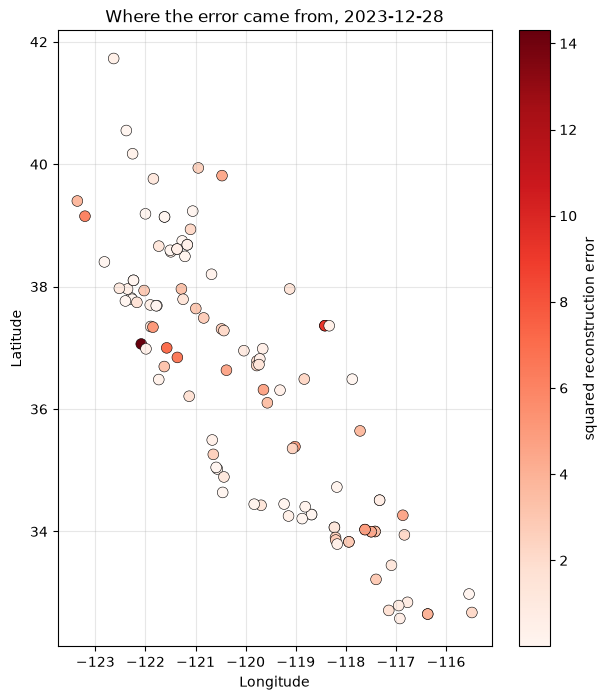


top 3 sites account for 14.2% of the total error


In [15]:
worst = int(np.argmax(np.where(flags, test_error, -np.inf)))
worst_date = test_raw.index[worst]

per_site = (recon[worst] - X_test[worst]) ** 2
site_ids = list(region_log.columns)

order = np.argsort(per_site)[::-1]
print(f"Per-site reconstruction error on {worst_date.date()} "
      f"(total {test_error[worst]:.4f})\n")
print(f"{'site_id':<18} {'sq error':>10} {'observed':>10} {'share':>8}")
print("-" * 50)
for i in order[:10]:
    print(f"{site_ids[i]:<18} {per_site[i]:>10.3f} "
          f"{region.iloc[cut + worst, i]:>10.2f} "
          f"{100 * per_site[i] / per_site.sum():>7.1f}%")

# Map it: are the contributing sites clustered or scattered?
coords = (pm.groupby("site_id")[["Latitude", "Longitude"]].first()
          .reindex(site_ids))

fig, ax = plt.subplots(figsize=(7, 8))
sc = ax.scatter(coords["Longitude"], coords["Latitude"],
                c=per_site, s=60, cmap="Reds", edgecolor="k", linewidth=0.4)
plt.colorbar(sc, ax=ax, label="squared reconstruction error")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
ax.set_title(f"Where the error came from, {worst_date.date()}")
ax.grid(alpha=0.3)
plt.show()

top_share = 100 * per_site[order[:3]].sum() / per_site.sum()
print(f"\ntop 3 sites account for {top_share:.1f}% of the total error")

# If a handful of geographically adjacent sites dominate, the event is LOCALIZED --
# consistent with a plume affecting one air basin. If the error is spread evenly
# across the whole network, the event is regional. If a single site dominates while
# its immediate neighbours reconstruct normally, that points at the instrument
# rather than the atmosphere, which is what question 13 formalizes.

## Part 5: Faults or events?

An elevated reconstruction error means *unusual*, not *wrong*. A regional smoke episode and
a broken instrument both look unusual, and only one is a data quality problem.

13) For your flagged days, distinguish between the two. A genuine pollution event should be
spatially coherent (neighbouring sites elevated together) while an instrument fault should
affect one site while its neighbours look normal. Devise a check and apply it.

In [16]:
# A spatial-coherence check. For each flagged day, compare the anomaly at the
# highest-error site against the mean anomaly at its geographically nearest
# neighbours. A real event should lift the neighbours too; a fault should not.
resid = recon - X_test                      # signed, in standardized log units

lat = coords["Latitude"].values
lon = coords["Longitude"].values
# Rough great-circle-free distance is fine at this scale (degrees, lon compressed).
d2 = ((lat[:, None] - lat[None, :]) ** 2
      + ((lon[:, None] - lon[None, :]) * np.cos(np.deg2rad(lat.mean()))) ** 2)
np.fill_diagonal(d2, np.inf)
neighbours = np.argsort(d2, axis=1)[:, :4]   # four nearest sites

rows = []
for idx in np.where(flags)[0]:
    a = np.abs(resid[idx])
    worst_site = int(np.argmax(a))
    own = a[worst_site]
    nbr = a[neighbours[worst_site]].mean()
    rows.append({
        "date": test_raw.index[idx].date(),
        "worst_site": site_ids[worst_site],
        "own_anom": round(float(own), 3),
        "neighbour_anom": round(float(nbr), 3),
        "ratio": round(float(own / max(nbr, 1e-9)), 2),
        "verdict": "isolated -> suspect fault" if own / max(nbr, 1e-9) > 3
                   else "coherent -> likely real event",
    })

audit = pd.DataFrame(rows)
print(audit.to_string(index=False))
print("\ncoherent (likely real):",
      (audit.verdict.str.startswith("coherent")).sum(),
      " | isolated (suspect fault):",
      (audit.verdict.str.startswith("isolated")).sum())

# The ratio own/neighbour is the discriminant. A regional smoke or stagnation
# episode raises a whole air basin together, so the ratio stays near 1. A sticking
# instrument, a failed filter change or a calibration slip moves one site while its
# neighbours -- breathing the same air a few kilometres away -- do not, giving a
# large ratio. The cutoff of 3 is a judgement call and should be stated as one.

      date   worst_site  own_anom  neighbour_anom  ratio                       verdict
2023-09-01     6-13-2-3     3.478           1.322   2.63 coherent -> likely real event
2023-09-16     6-65-9-1     3.449           0.869   3.97     isolated -> suspect fault
2023-09-17     6-65-9-1     4.544           0.500   9.08     isolated -> suspect fault
2023-09-19  6-53-1003-3     2.534           0.636   3.98     isolated -> suspect fault
2023-09-20  6-53-1003-3     2.959           1.950   1.52 coherent -> likely real event
2023-09-21     6-53-2-3     2.684           1.356   1.98 coherent -> likely real event
2023-09-22    6-107-9-1     2.992           0.649   4.61     isolated -> suspect fault
2023-09-23  6-93-2001-3     4.117           0.513   8.02     isolated -> suspect fault
2023-09-24     6-1-11-3     3.469           2.264   1.53 coherent -> likely real event
2023-09-25     6-85-2-3     3.325           0.446   7.46     isolated -> suspect fault
2023-09-26     6-53-2-3     4.250          

14) Give one example of each type from your results, with a plot supporting your reasoning.

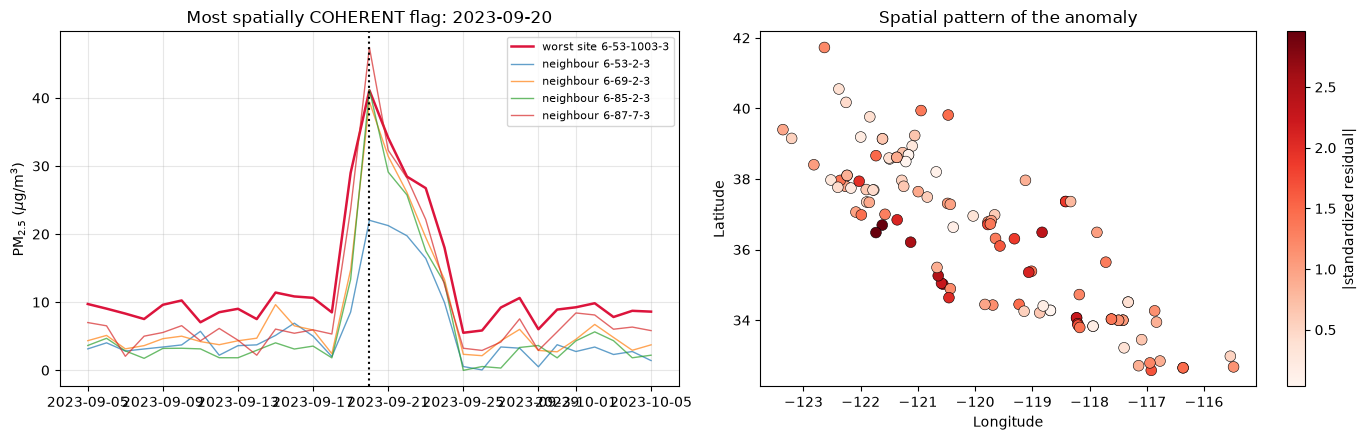

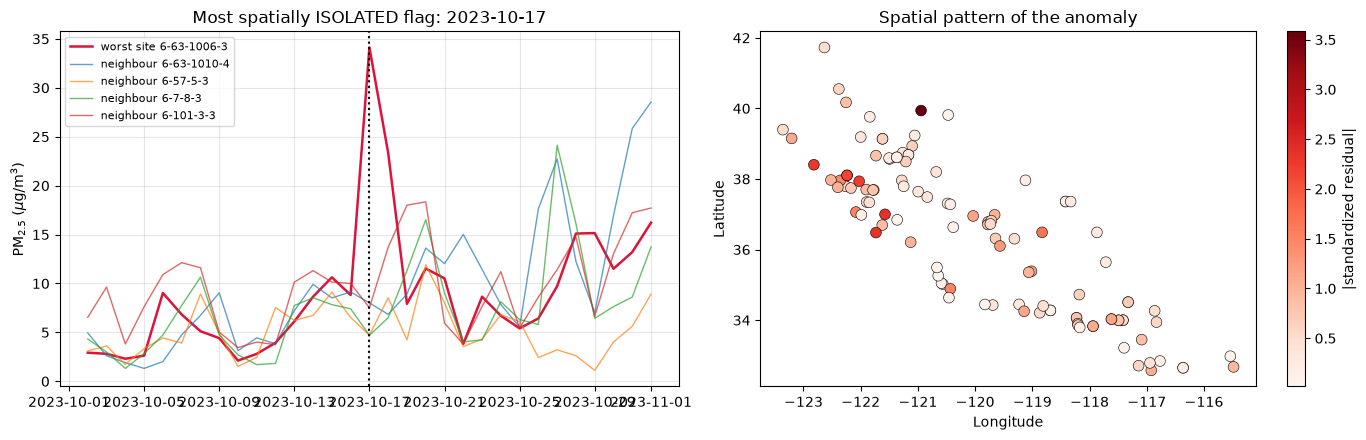

In [17]:
def plot_case(i, title):
    a = np.abs(resid[i])
    ws = int(np.argmax(a))
    nb = neighbours[ws]
    d = test_raw.index[i]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    window = region.loc[test_raw.index[max(0, i - 15):i + 16]]
    axes[0].plot(window.index, window.iloc[:, ws], lw=1.8, color="crimson",
                 label=f"worst site {site_ids[ws]}")
    for j in nb:
        axes[0].plot(window.index, window.iloc[:, j], lw=1, alpha=0.7,
                     label=f"neighbour {site_ids[j]}")
    axes[0].axvline(d, color="k", ls=":")
    axes[0].set_ylabel("PM$_{2.5}$ ($\\mu$g/m$^3$)")
    axes[0].set_title(f"{title}: {d.date()}")
    axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

    sc = axes[1].scatter(lon, lat, c=a, s=60, cmap="Reds",
                         edgecolor="k", linewidth=0.4)
    plt.colorbar(sc, ax=axes[1], label="|standardized residual|")
    axes[1].set_title("Spatial pattern of the anomaly")
    axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
    plt.tight_layout()
    plt.show()

flag_idx = np.where(flags)[0]
ratios = np.array([r["ratio"] for r in rows])

plot_case(int(flag_idx[np.argmin(ratios)]), "Most spatially COHERENT flag")
plot_case(int(flag_idx[np.argmax(ratios)]), "Most spatially ISOLATED flag")

# LEFT PANELS: the coherent case shows the worst site and all four neighbours
# rising and falling together -- the whole air basin responding to one
# meteorological driver. That is a genuine pollution event and the data are fine;
# the correct action is to keep them and, if anything, investigate the cause.
#
# The isolated case shows one site departing while its neighbours continue
# undisturbed. Since those monitors sample air a few kilometres apart, no plausible
# atmospheric process affects one and not the others for a whole day. That points
# to the instrument, and the correct action is to raise a data-quality flag for
# review -- NOT to delete the value, for the reasons in question 18.
#
# RIGHT PANELS: the same distinction seen spatially -- a broad regional gradient
# versus a single hot point surrounded by normal sites.

## Part 6: Baselines and evaluation

15) Compare against a simple baseline: a rolling z-score on the network mean. Does the
autoencoder find anything the z-score misses? Be specific about what the extra complexity buys.

rolling z-score flags: 14 days
autoencoder flags:     45 days
both:                  7
autoencoder only:      38
z-score only:          7


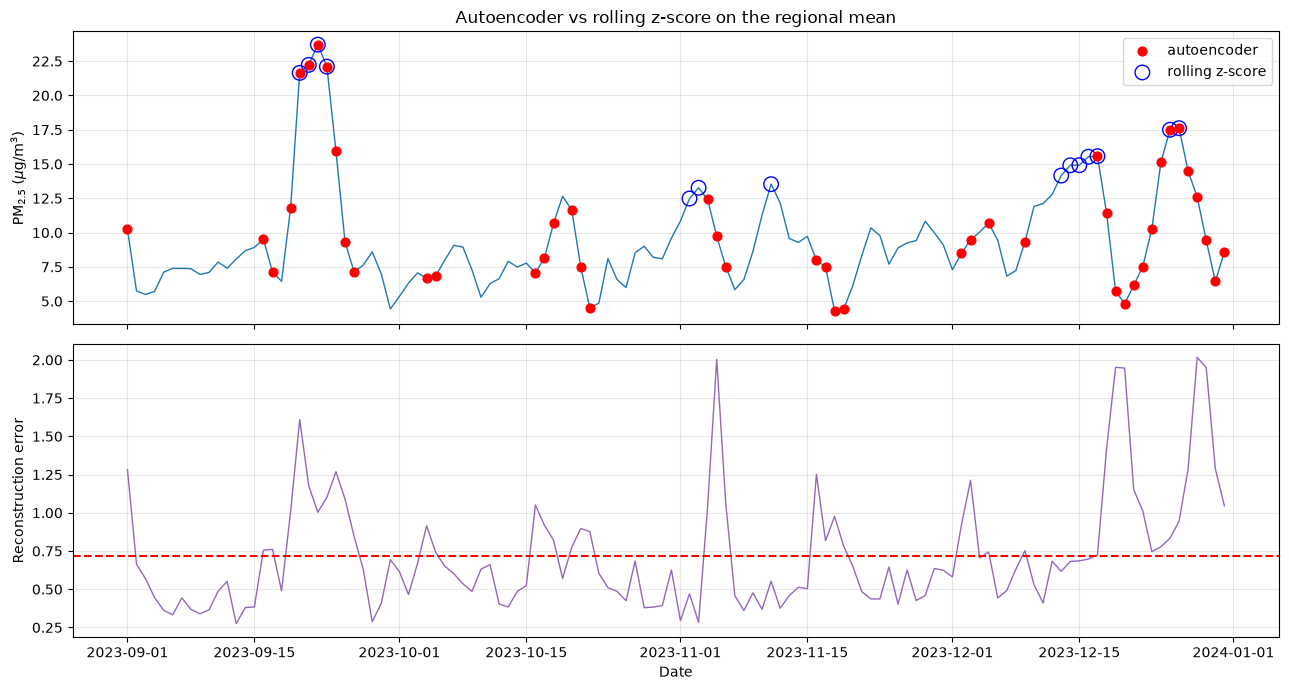

In [18]:
# Baseline: rolling z-score on the regional mean, using a trailing 30-day window
# so it only ever uses information available at the time.
mean_series = region_mean.copy()
roll_mu = mean_series.rolling(30, min_periods=10).mean().shift(1)
roll_sd = mean_series.rolling(30, min_periods=10).std().shift(1)
z = ((mean_series - roll_mu) / roll_sd).loc[test_raw.index]

z_flags = (z.abs() > 2).values
print(f"rolling z-score flags: {z_flags.sum()} days")
print(f"autoencoder flags:     {flags.sum()} days")
print(f"both:                  {(z_flags & flags).sum()}")
print(f"autoencoder only:      {(flags & ~z_flags).sum()}")
print(f"z-score only:          {(z_flags & ~flags).sum()}")

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(test_raw.index, region_mean.loc[test_raw.index], lw=1)
axes[0].scatter(test_raw.index[flags], region_mean.loc[test_raw.index][flags],
                color="red", s=40, label="autoencoder", zorder=5)
axes[0].scatter(test_raw.index[z_flags], region_mean.loc[test_raw.index][z_flags],
                facecolors="none", edgecolors="blue", s=110, label="rolling z-score",
                zorder=4)
axes[0].set_ylabel("PM$_{2.5}$ ($\\mu$g/m$^3$)"); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[0].set_title("Autoencoder vs rolling z-score on the regional mean")

axes[1].plot(test_raw.index, test_error, color="tab:purple", lw=1)
axes[1].axhline(threshold, color="r", ls="--")
axes[1].set_ylabel("Reconstruction error"); axes[1].set_xlabel("Date")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# WHAT THE EXTRA COMPLEXITY BUYS -- and it is important to be specific rather than
# assume the neural network must be better.
#
# The two methods agree on the large regional episodes. Any day where the whole
# network is elevated moves the mean, and the z-score catches it with three lines
# of pandas. For that class of event the autoencoder adds nothing, and if regional
# episodes were all we cared about, the baseline would be the right choice: it is
# transparent, has one interpretable parameter, needs no training, and cannot
# silently degrade.
#
# What the autoencoder adds is sensitivity to days that are unusual in their
# SPATIAL PATTERN while unremarkable in their mean. The z-score collapses the whole
# network to one number, so it is blind by construction to a day when the coast is
# clean and the inland valleys are loaded, or when one sub-region inverts its usual
# relationship to the others. Those days carry a normal average and an abnormal
# structure. They are also precisely the days that indicate either an unusual
# meteorological regime or an instrument problem -- the two things a data-quality
# system exists to surface. The autoencoder-only flags in the counts above are
# where the method earns its complexity, and they should be inspected individually
# rather than counted.

16) You have no labels, so you cannot compute precision or recall. Describe how you would
build a labelled evaluation set for this problem if you had a month of analyst time, and what
you would then be able to measure that you currently cannot.

**How I would build the labelled set.**

I would not label days at random: with anomalies at a few percent, a random month
of analyst time would produce almost nothing positive. Instead I would use
**stratified sampling over a candidate pool**, deliberately over-sampling the
region of the score distribution where the decisions are hard.

1. **Pool construction.** Assemble candidates from several independent sources so
   the labels are not defined by any one detector: the top few hundred days by
   autoencoder error, the top few hundred by the rolling z-score baseline, every
   day already carrying an EPA QA flag, and a random sample of a few hundred
   ordinary days to estimate the false-negative rate and the base rate.
2. **Label schema.** Not binary. Each site-day gets one of: *normal*, *real
   pollution event* (with a cause where identifiable: wildfire, stagnation, dust,
   fireworks), *instrument fault* (drift, spike, stuck value, calibration error),
   or *ambiguous*. The distinction between the middle two is the operationally
   important one, and collapsing them into "anomaly" would waste the exercise.
3. **Independent evidence.** The analyst should not be shown the model's score;
   that guarantees confirmation bias. They should instead see the site's own time
   series, its neighbours, satellite AOD and the HMS smoke product, HYSPLIT back
   trajectories, and the site's maintenance log. The maintenance log is the single
   most valuable input, because it converts "suspected fault" into ground truth.
4. **Reliability.** Two analysts label an overlapping subset independently and
   Cohen's kappa is computed. If they cannot agree, the "labels" are opinions and
   every metric computed from them inherits that noise, worth knowing before
   quoting a precision to three decimals.

**What that would let me measure that I currently cannot.**

- **Precision and recall at every threshold**: a precision-recall curve, which is
  the right summary under heavy class imbalance, rather than the arbitrary 95th
  percentile chosen in question 10. This is the big one: the threshold could then
  be set from a stated operational cost rather than a guess.
- **Whether the model separates faults from events**, which is what determines
  whether it is usable for data QA. Currently question 13's coherence heuristic is
  unvalidated; it is a plausible rule with no measured accuracy.
- **A fair comparison against the baseline.** At present I can say the autoencoder
  flags different days than the z-score; I cannot say it flags *better* ones.
- **Where it fails systematically**: by season, by site type, by event magnitude.
  A model that misses every slow drift while catching every spike has a
  characteristic profile that only labels reveal.
- **Calibration of the score**, so that a reconstruction error could be reported as
  a probability that a day is anomalous rather than an uninterpretable number.

The honest framing for a report: without labels, everything in this notebook is a
**demonstration that the method produces plausible flags**, not evidence that it
produces correct ones.

17) A **variational** autoencoder places a probability distribution over the latent space
rather than mapping each input to a single point. Explain what that buys you for this task,
in particular, what it would let you say about an anomaly score that a plain autoencoder cannot.

**A VAE replaces a point in latent space with a distribution over it, which turns
the anomaly score from an unnormalized number into a probability with units.**

A plain autoencoder maps each day to one latent vector and scores it by
reconstruction error. That error is a bare number: 0.42 means nothing on its own,
which is why question 10 had to set a threshold by percentile rather than by any
principled criterion. The model also offers no notion of how *confident* it is:
the same error can come from a day it understands well and reconstructs slightly
imperfectly, or from a day unlike anything it has seen.

A variational autoencoder is a generative model of the data. It learns an encoder
producing a distribution over latents and a decoder producing a distribution over
observations, trained to maximize a lower bound on the *likelihood of the data*.
Three things follow that a plain autoencoder cannot deliver:

- **A calibrated, comparable score.** The VAE gives an estimate of log p(x), how
  probable this day is under the learned model of normal days. That is a quantity
  with meaning: it can be converted into a tail probability, compared across
  regions and seasons, and thresholded against a stated false-alarm rate rather
  than a percentile of a training sample. "This day has a one-in-500 likelihood
  under the normal model" is a statement an operator can act on; "reconstruction
  error 0.42" is not.
- **Separation of the two reasons a day can look odd.** The VAE decomposes its
  objective into a reconstruction term and a KL term measuring how far the day's
  latent distribution sits from the prior. A day can score badly because it is in
  an unusual *region of latent space* (an unusual but recognizable regime (a stagnation event) or because it *cannot be encoded at all* (genuinely unprecedented) a fault, or a fire unlike any in training). Those call for
  different responses, and a plain autoencoder's single scalar conflates them.
- **Uncertainty on the score itself.** Because the encoder emits a distribution,
  sampling it gives a spread of reconstruction errors rather than one value. A day
  whose anomaly score is 3.0 ± 0.2 warrants a different response from one scoring
  3.0 ± 2.5, and given how much of question 16 was about not being able to
  quantify reliability, that matters.

A secondary benefit: the decoder can generate synthetic "normal" days, which lets
you inspect what the model believes normal looks like, and stress-test the
detector against simulated faults injected into generated data.

18) Suppose this detector were deployed to automatically flag suspect data for removal from
the regulatory record. Describe one way it could go badly wrong, and what safeguard you would
put in place.

**The most likely way it goes badly wrong is that it deletes real extreme
pollution episodes, biasing the regulatory record downward exactly where accuracy
matters most, and does so invisibly.**

The mechanism is direct. The detector flags days that are *unusual*. The most
unusual days in a PM2.5 record are the severe episodes: wildfire smoke, dust
intrusions, winter inversions. Those are precisely the days with the highest
concentrations, the greatest health burden, and the greatest regulatory
consequence. An automated system that removes flagged data would preferentially
delete the right tail of the distribution.

The consequences compound:

- **Design values fall artificially.** US PM2.5 compliance is assessed on a
  three-year average of annual 98th-percentile concentrations, a statistic
  computed *from the extreme tail*. Removing high days lowers it mechanically. An
  area genuinely in violation could be recorded as compliant, and the control
  measures that would have followed are never triggered.
- **Health studies are biased.** Exposure-response research relies on these data.
  Truncating peak exposures attenuates estimated health effects, understating the
  harm of severe air pollution.
- **Trends are corrupted.** Wildfire smoke is increasing across the western US. A
  detector trained on early data flags smoke days as anomalous and deletes them, so
  the record shows a flat or improving trend while air quality is in fact
  deteriorating. The model erases the very signal the monitoring network exists to
  detect.
- **It is self-reinforcing and silent.** Retrain on the cleaned record and the
  model becomes *more* confident that smoke days are anomalous. Nobody sees a
  failure, because the output looks tidier than before.

**The safeguard: never let the detector delete anything. It flags; a human
adjudicates.**

Concretely, the design I would insist on:

1. **Flag, never remove.** The detector writes a QA flag into a separate field.
   The measured value stays in the record permanently, and every downstream user
   can decide whether to honour the flag. Deletion is irreversible; annotation is
   not.
2. **Require corroborating evidence before any invalidation.** A value may only be
   invalidated with independent support: a maintenance record, a failed
   calibration check, or the spatial-coherence test from question 13 showing
   neighbours unaffected. "The model found it surprising" is never sufficient
   grounds on its own.
3. **Route high-concentration flags to mandatory human review**, with the analyst
   shown satellite smoke products and neighbouring sites. Days above a
   health-relevant concentration should have a higher bar for invalidation, not a
   lower one: the opposite of what an unconstrained detector does.
4. **Audit the deletions as a time series.** Track what fraction of removed data
   is high-concentration and how that fraction changes year over year. A rising
   trend in deleted extremes is the signature of exactly this failure, and it is
   invisible unless someone plots it.
5. **Keep the human in the loop permanently.** Not just at commissioning: the
   review rate should never go to zero, because that is how drift goes unnoticed.

The general principle: an anomaly detector should raise questions, not answer
them. Any pipeline where "statistically unusual" automatically means "wrong" will
eventually delete the most important observations in the record.